# Introduction to Quantum Information and Quantum Machine Learning

## Lab 4

Mateusz Tabaszewski 151945

## Introduction

This lab shows the implementation of different forms of Grover’s oracle and the Grover diffusion operator. The XOR and phase oracles are presented along with Grover's Diffusion operators and the associated mathematical derivations

## Imports

In [1]:
import math
from math import sqrt
from numpy import pi 
from qiskit import *
from qiskit.quantum_info import Statevector, Operator
from qiskit import QuantumRegister, ClassicalRegister, QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import *
import numpy as np

## Task 1 : 

In [2]:
backend = AerSimulator(method='unitary')
experiment_backend = AerSimulator()

### XOR Oracle

In [3]:
xor_oracle = Operator([[1, 0, 0, 0, 0, 0, 0, 0],
                       [0, 0, 0, 0, 0, 1, 0, 0],
                       [0, 0, 1, 0, 0, 0, 0, 0],
                       [0, 0, 0, 1, 0, 0, 0, 0],
                       [0, 0, 0, 0, 1, 0, 0, 0],
                       [0, 1, 0, 0, 0, 0, 0, 0],
                       [0, 0, 0, 0, 0, 0, 1, 0],
                       [0, 0, 0, 0, 0, 0, 0, 1],])
Operator.is_unitary(xor_oracle)

True

### Phase Oracle

In [4]:
phase_oracle = Operator([[1, 0, 0, 0, 0, 0, 0, 0],
                       [0, 1, 0, 0, 0, 0, 0, 0],
                       [0, 0, 1, 0, 0, 0, 0, 0],
                       [0, 0, 0, 1, 0, 0, 0, 0],
                       [0, 0, 0, 0, -1, 0, 0, 0],
                       [0, 0, 0, 0, 0, 1, 0, 0],
                       [0, 0, 0, 0, 0, 0, 1, 0],
                       [0, 0, 0, 0, 0, 0, 0, 1],])
Operator.is_unitary(phase_oracle)

True

## Task 2 : Gate

### XOR Oracle

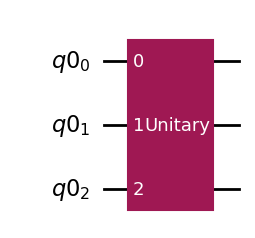

In [5]:
n0=3
q0 = QuantumRegister(n0)
XOR_circuit = QuantumCircuit(q0, name='Uf')
XOR_circuit.append(xor_oracle,[0, 1, 2])

XOR_gate = XOR_circuit.to_gate()
XOR_circuit.draw(output='mpl')

In [6]:
XOR_gate

Instruction(name='Uf', num_qubits=3, num_clbits=0, params=[])

In [7]:
Operator(XOR_circuit)

Operator([[1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j],
          [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j]],
         input_dims=(2, 2, 2), output_dims=(2, 2, 2))


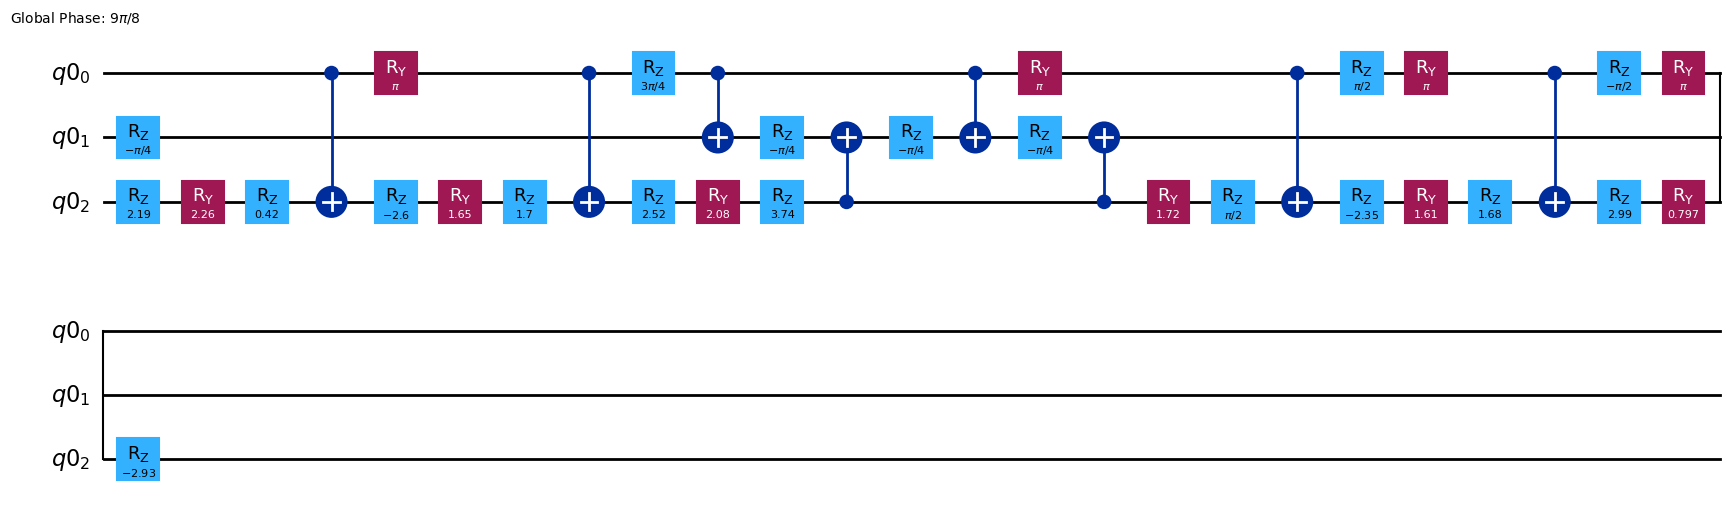

In [8]:
XOR_circuit_transpiled = transpile(XOR_circuit,  basis_gates=['cx', 'rz', 'ry', 'h'])
XOR_circuit_transpiled.draw(output='mpl') 

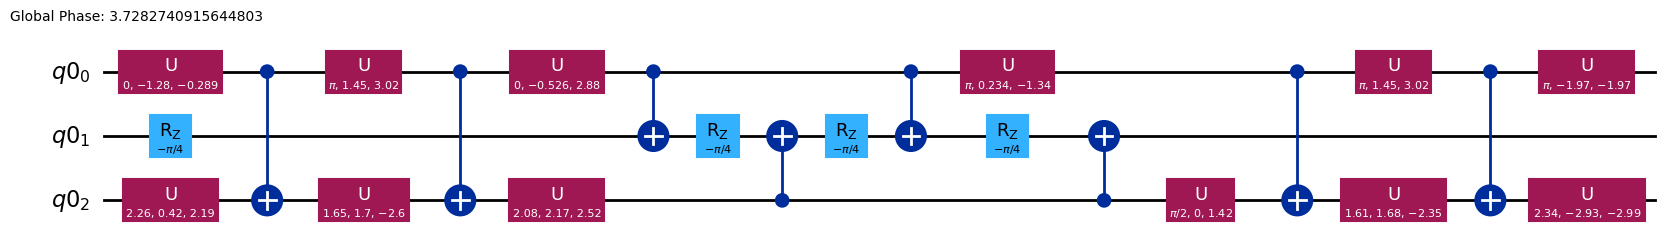

In [9]:
XOR_circuit_decomp=XOR_circuit.decompose(reps=2)
XOR_circuit_decomp.draw(output='mpl') 

In [10]:
circuit_to_run = XOR_circuit_transpiled.copy()
circuit_to_run.save_unitary()
job = backend.run(circuit_to_run)
results = job.result()
print(results.get_unitary(circuit_to_run, decimals=3))

Operator([[ 1.-0.j,  0.-0.j,  0.+0.j,  0.+0.j, -0.-0.j,  0.-0.j,  0.+0.j,
            0.+0.j],
          [-0.-0.j,  0.-0.j,  0.+0.j,  0.+0.j,  0.-0.j,  1.-0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  1.-0.j,  0.-0.j,  0.+0.j,  0.+0.j,  0.-0.j,
            0.-0.j],
          [ 0.+0.j,  0.+0.j, -0.-0.j,  1.-0.j,  0.+0.j,  0.+0.j,  0.-0.j,
           -0.-0.j],
          [ 0.-0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.-0.j, -0.-0.j,  0.+0.j,
            0.+0.j],
          [-0.-0.j,  1.-0.j,  0.+0.j,  0.+0.j, -0.+0.j, -0.-0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.-0.j, -0.+0.j,  0.+0.j,  0.+0.j,  1.-0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j, -0.-0.j,  0.-0.j,  0.+0.j,  0.+0.j, -0.+0.j,
            1.-0.j]],
         input_dims=(2, 2, 2), output_dims=(2, 2, 2))


In [11]:
circuit_to_run = XOR_circuit_decomp.copy()
circuit_to_run.save_unitary()
job = backend.run(circuit_to_run)
results = job.result()
print(results.get_unitary(circuit_to_run, decimals=3))

Operator([[ 1.+0.j, -0.+0.j,  0.+0.j,  0.+0.j, -0.+0.j, -0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -0.-0.j,  1.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  1.+0.j, -0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
           -0.-0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j, -0.-0.j,
           -0.+0.j],
          [-0.+0.j, -0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.-0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.-0.j,  0.+0.j,  0.+0.j,  1.+0.j,
           -0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.-0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            1.+0.j]],
         input_dims=(2, 2, 2), output_dims=(2, 2, 2))


### Phase Oracle

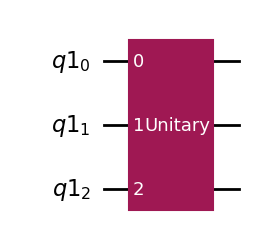

In [12]:
n0=3
q0 = QuantumRegister(n0)
phase_circuit = QuantumCircuit(q0, name='Uf')
phase_circuit.append(phase_oracle,[0, 1, 2])

phase_gate = phase_circuit.to_gate()
phase_circuit.draw(output='mpl')

In [13]:
phase_gate

Instruction(name='Uf', num_qubits=3, num_clbits=0, params=[])

In [14]:
Operator(phase_circuit)

Operator([[ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  1.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            1.+0.j]],
         input_dims=(2, 2, 2), output_dims=(2, 2, 2))


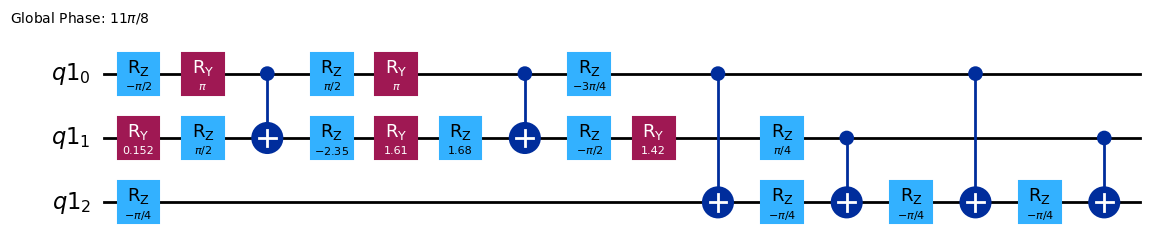

In [15]:
phase_circuit_transpiled = transpile(phase_circuit, basis_gates=['cx', 'rz', 'ry', 'h'])
phase_circuit_transpiled.draw(output='mpl') 

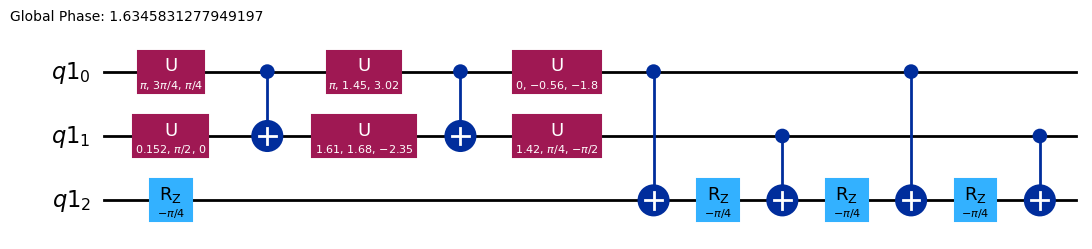

In [16]:
phase_circuit_decomp=phase_circuit.decompose(reps=2)
phase_circuit_decomp.draw(output='mpl') 

In [17]:
circuit_to_run = phase_circuit_transpiled.copy()
circuit_to_run.save_unitary()
job = backend.run(circuit_to_run)
results = job.result()
print(results.get_unitary(circuit_to_run, decimals=3))

Operator([[ 1.-0.j, -0.-0.j,  0.-0.j, -0.-0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [-0.-0.j,  1.-0.j,  0.+0.j, -0.-0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [-0.-0.j,  0.+0.j,  1.-0.j, -0.-0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [-0.-0.j,  0.-0.j, -0.-0.j,  1.-0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j,  0.+0.j, -0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -0.-0.j,  1.-0.j,  0.+0.j,
           -0.-0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -0.-0.j,  0.+0.j,  1.-0.j,
           -0.-0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -0.-0.j,  0.-0.j, -0.-0.j,
            1.-0.j]],
         input_dims=(2, 2, 2), output_dims=(2, 2, 2))


In [18]:
circuit_to_run = phase_circuit_decomp.copy()
circuit_to_run.save_unitary()
job = backend.run(circuit_to_run)
results = job.result()
print(results.get_unitary(circuit_to_run, decimals=3))

Operator([[ 1.+0.j,  0.-0.j,  0.-0.j, -0.-0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [-0.-0.j,  1.+0.j, -0.+0.j,  0.-0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [-0.-0.j,  0.+0.j,  1.+0.j, -0.-0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.-0.j, -0.-0.j,  0.-0.j,  1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j, -0.+0.j, -0.+0.j,
            0.+0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -0.-0.j,  1.+0.j, -0.+0.j,
            0.-0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j, -0.-0.j,  0.+0.j,  1.+0.j,
           -0.-0.j],
          [ 0.+0.j,  0.+0.j,  0.+0.j,  0.+0.j,  0.-0.j, -0.-0.j,  0.-0.j,
            1.+0.j]],
         input_dims=(2, 2, 2), output_dims=(2, 2, 2))


## Task 3 :

In [19]:
n = 3
dim = 2**n

ket0 = np.zeros((dim, 1))
ket0[0, 0] = 1

proj = ket0 @ ket0.T

print(proj)

[[1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


## Task 4 :

In [20]:
n = 3
dim = 2**n

ket0 = np.zeros((dim, 1))
ket0[0, 0] = 1
proj = ket0 @ ket0.T
sol = 2 * ket0 @ ket0.T - np.eye(proj.shape[0], proj.shape[1])
print(sol)

[[ 1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.]]


## Task 5 :

In [21]:
n = 3
dim = 2**n

ket0 = np.zeros((dim, 1))
ket0[0, 0] = 1
proj = ket0 @ ket0.T
X_1 = np.array([[0, 1],
               [1, 0]])
X_n = X_1
for i in range(1, n):
    X_n = np.kron(X_n, X_1)

lhs = X_n @ (2 * ket0 @ ket0.T - np.eye(proj.shape[0], proj.shape[1])) @ X_n

ket1 = np.zeros((dim, 1))
ket1[-1, -1] = 1
rhs = 2 * ket1 @ ket1.T - np.eye(proj.shape[0], proj.shape[1])
print(f"Left Hand Side:\n {lhs}")
print(f"Right Hand Side:\n {rhs}")
print(f"Equal: {np.allclose(lhs, rhs)}")

Left Hand Side:
 [[-1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  1.]]
Right Hand Side:
 [[-1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0.  1.]]
Equal: True


## Task 6 : Grover's Diffusion Operator

In [22]:
n = 3
dim = 2**n

phi = 1/sqrt(dim) * np.ones((dim, 1))
W = 2 * phi @ phi.T - np.eye(dim, dim)
print(W)

[[-0.75  0.25  0.25  0.25  0.25  0.25  0.25  0.25]
 [ 0.25 -0.75  0.25  0.25  0.25  0.25  0.25  0.25]
 [ 0.25  0.25 -0.75  0.25  0.25  0.25  0.25  0.25]
 [ 0.25  0.25  0.25 -0.75  0.25  0.25  0.25  0.25]
 [ 0.25  0.25  0.25  0.25 -0.75  0.25  0.25  0.25]
 [ 0.25  0.25  0.25  0.25  0.25 -0.75  0.25  0.25]
 [ 0.25  0.25  0.25  0.25  0.25  0.25 -0.75  0.25]
 [ 0.25  0.25  0.25  0.25  0.25  0.25  0.25 -0.75]]


In [23]:
n = 3
dim = 2**n

ket0 = np.zeros((dim, 1))
ket0[0, 0] = 1
H_1 = 1/sqrt(2) * np.array([[1, 1],
                            [1, -1]])
H_n = H_1
for i in range(1, n):
    H_n = np.kron(H_n, H_1)

W = H_n @ (2* ket0 @ ket0.T - np.eye(dim, dim)) @ H_n 
print(W)

[[-0.75  0.25  0.25  0.25  0.25  0.25  0.25  0.25]
 [ 0.25 -0.75  0.25  0.25  0.25  0.25  0.25  0.25]
 [ 0.25  0.25 -0.75  0.25  0.25  0.25  0.25  0.25]
 [ 0.25  0.25  0.25 -0.75  0.25  0.25  0.25  0.25]
 [ 0.25  0.25  0.25  0.25 -0.75  0.25  0.25  0.25]
 [ 0.25  0.25  0.25  0.25  0.25 -0.75  0.25  0.25]
 [ 0.25  0.25  0.25  0.25  0.25  0.25 -0.75  0.25]
 [ 0.25  0.25  0.25  0.25  0.25  0.25  0.25 -0.75]]


## Task 7 :

### XOR Operator

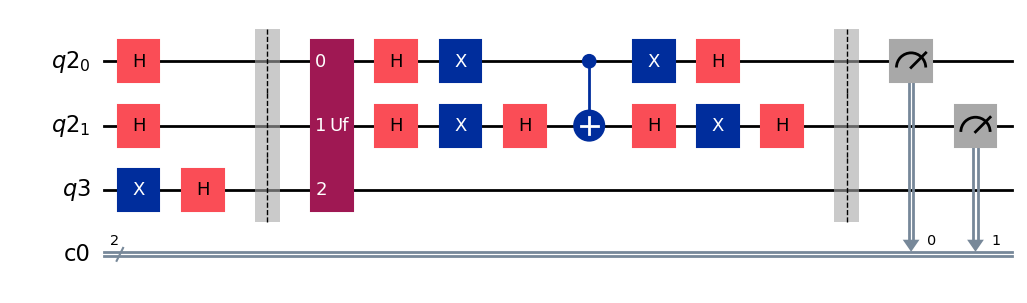

In [24]:
n0 = 3
q0 = QuantumRegister(n0 - 1)
ancilla = QuantumRegister(1)
c0 = ClassicalRegister(n0 - 1)
W_XOR_circuit = QuantumCircuit(q0, ancilla, c0, name='W_XOR')

W_XOR_circuit.x(ancilla)
W_XOR_circuit.h(ancilla)
W_XOR_circuit.h(q0)
W_XOR_circuit.barrier()

num_iter = int(pi/4 * sqrt(2**(n0-1)))

for i in range(num_iter):
    W_XOR_circuit.append(XOR_gate, [q0[0], q0[1], ancilla])
    W_XOR_circuit.h(q0)
    W_XOR_circuit.x(q0)
    W_XOR_circuit.h(q0[1])
    W_XOR_circuit.cx(q0[0], q0[1])
    W_XOR_circuit.h(q0[1])
    W_XOR_circuit.x(q0)
    W_XOR_circuit.h(q0)
    W_XOR_circuit.barrier()

W_XOR_circuit.measure(q0, c0)
W_XOR_circuit.draw(output='mpl')

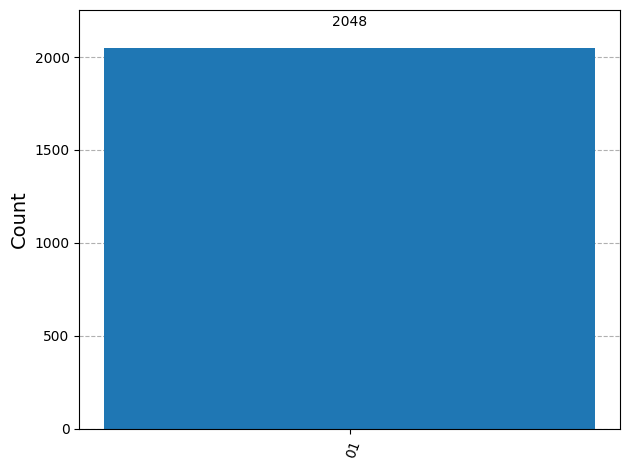

In [25]:
W_XOR_circuit_transpiled = transpile(W_XOR_circuit, experiment_backend)
job = experiment_backend.run(W_XOR_circuit_transpiled, shots=2048)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

### Phase Operator

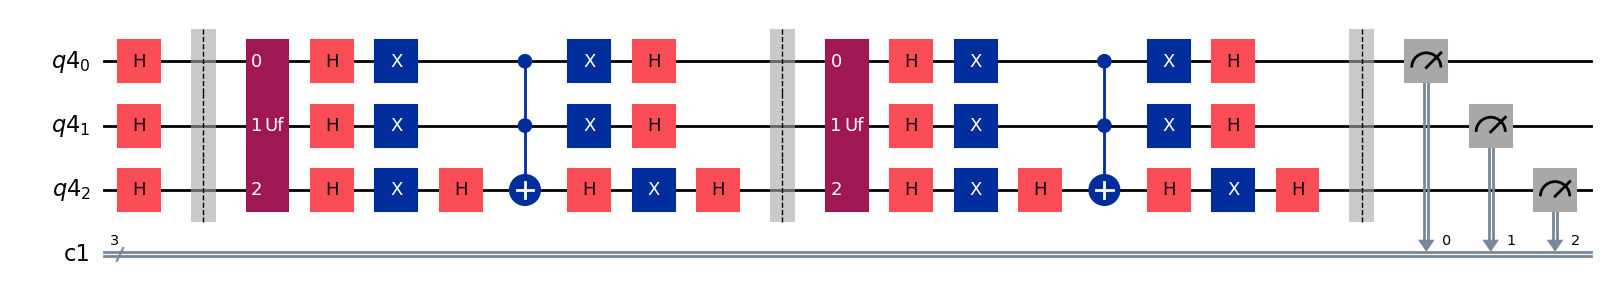

In [26]:
n0 = 3
q0 = QuantumRegister(n0)
c0 = ClassicalRegister(n0)
W_Phase_circuit = QuantumCircuit(q0, c0, name='W_XOR')

W_Phase_circuit.h(q0)
W_Phase_circuit.barrier()

num_iter = int(pi/4 * sqrt(2**n0))

for i in range(num_iter):
    W_Phase_circuit.append(phase_gate, [0, 1, 2])
    W_Phase_circuit.h(q0)
    W_Phase_circuit.x(q0)
    W_Phase_circuit.h(q0[2])
    W_Phase_circuit.ccx(q0[0], q0[1], q0[2])
    W_Phase_circuit.h(q0[2])
    W_Phase_circuit.x(q0)
    W_Phase_circuit.h(q0)
    W_Phase_circuit.barrier()

W_Phase_circuit.measure(q0, c0)
W_Phase_circuit.draw(output='mpl')

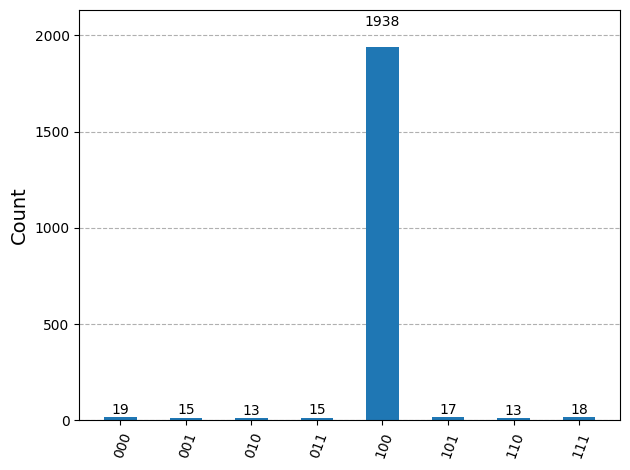

In [27]:
W_Phase_circuit_transpiled = transpile(W_Phase_circuit, experiment_backend)
job = experiment_backend.run(W_Phase_circuit_transpiled, shots=2048)
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

## Tasks 3-6 (Manual Calculations)

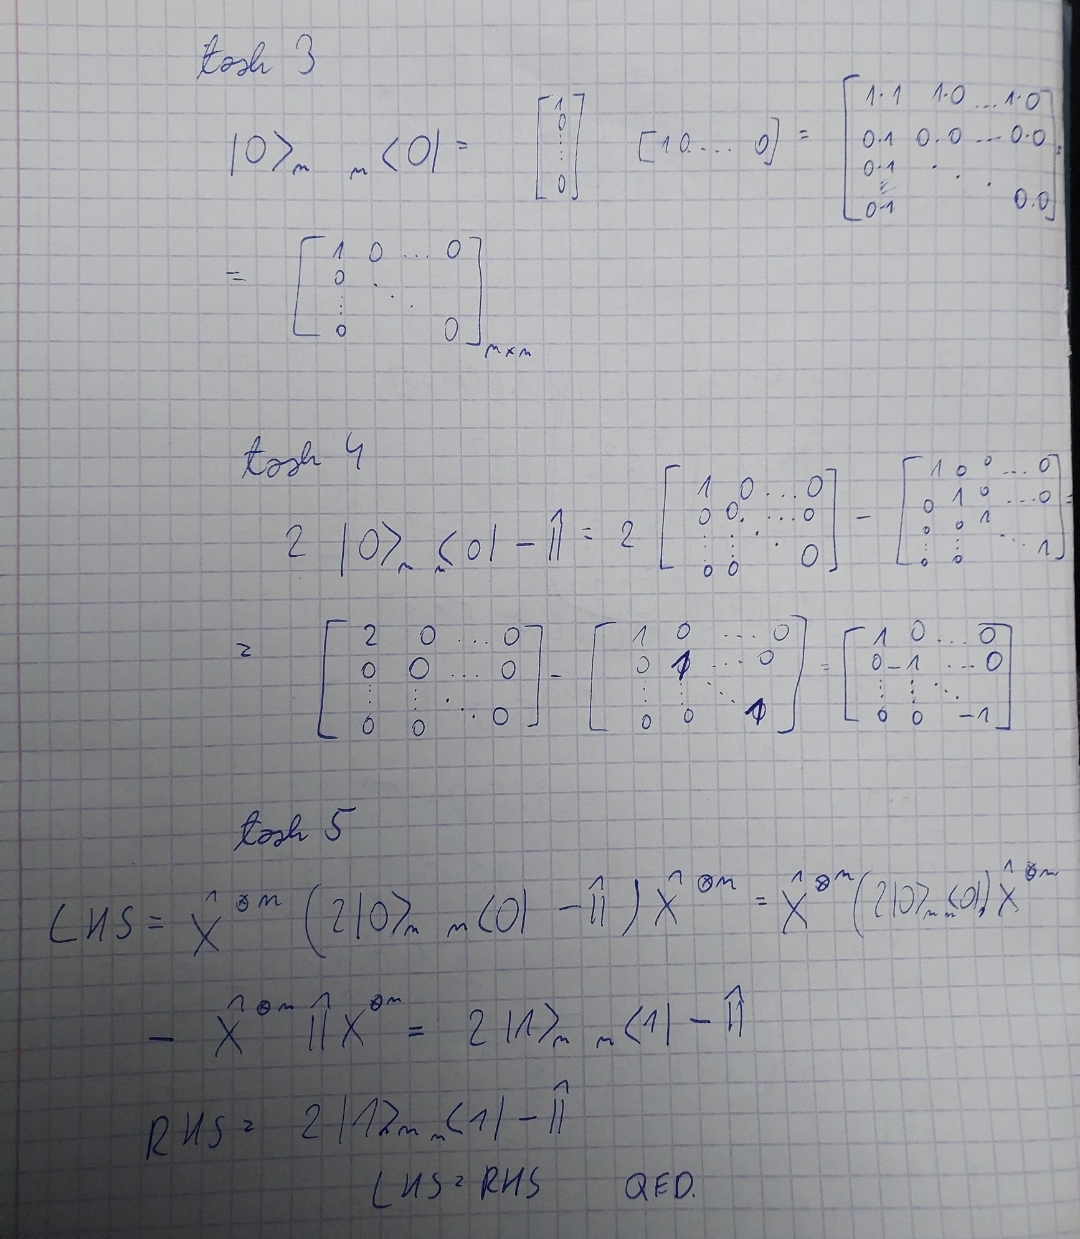

In [1]:
from IPython.display import Image
Image(filename="images/tasks3-5.jpg")

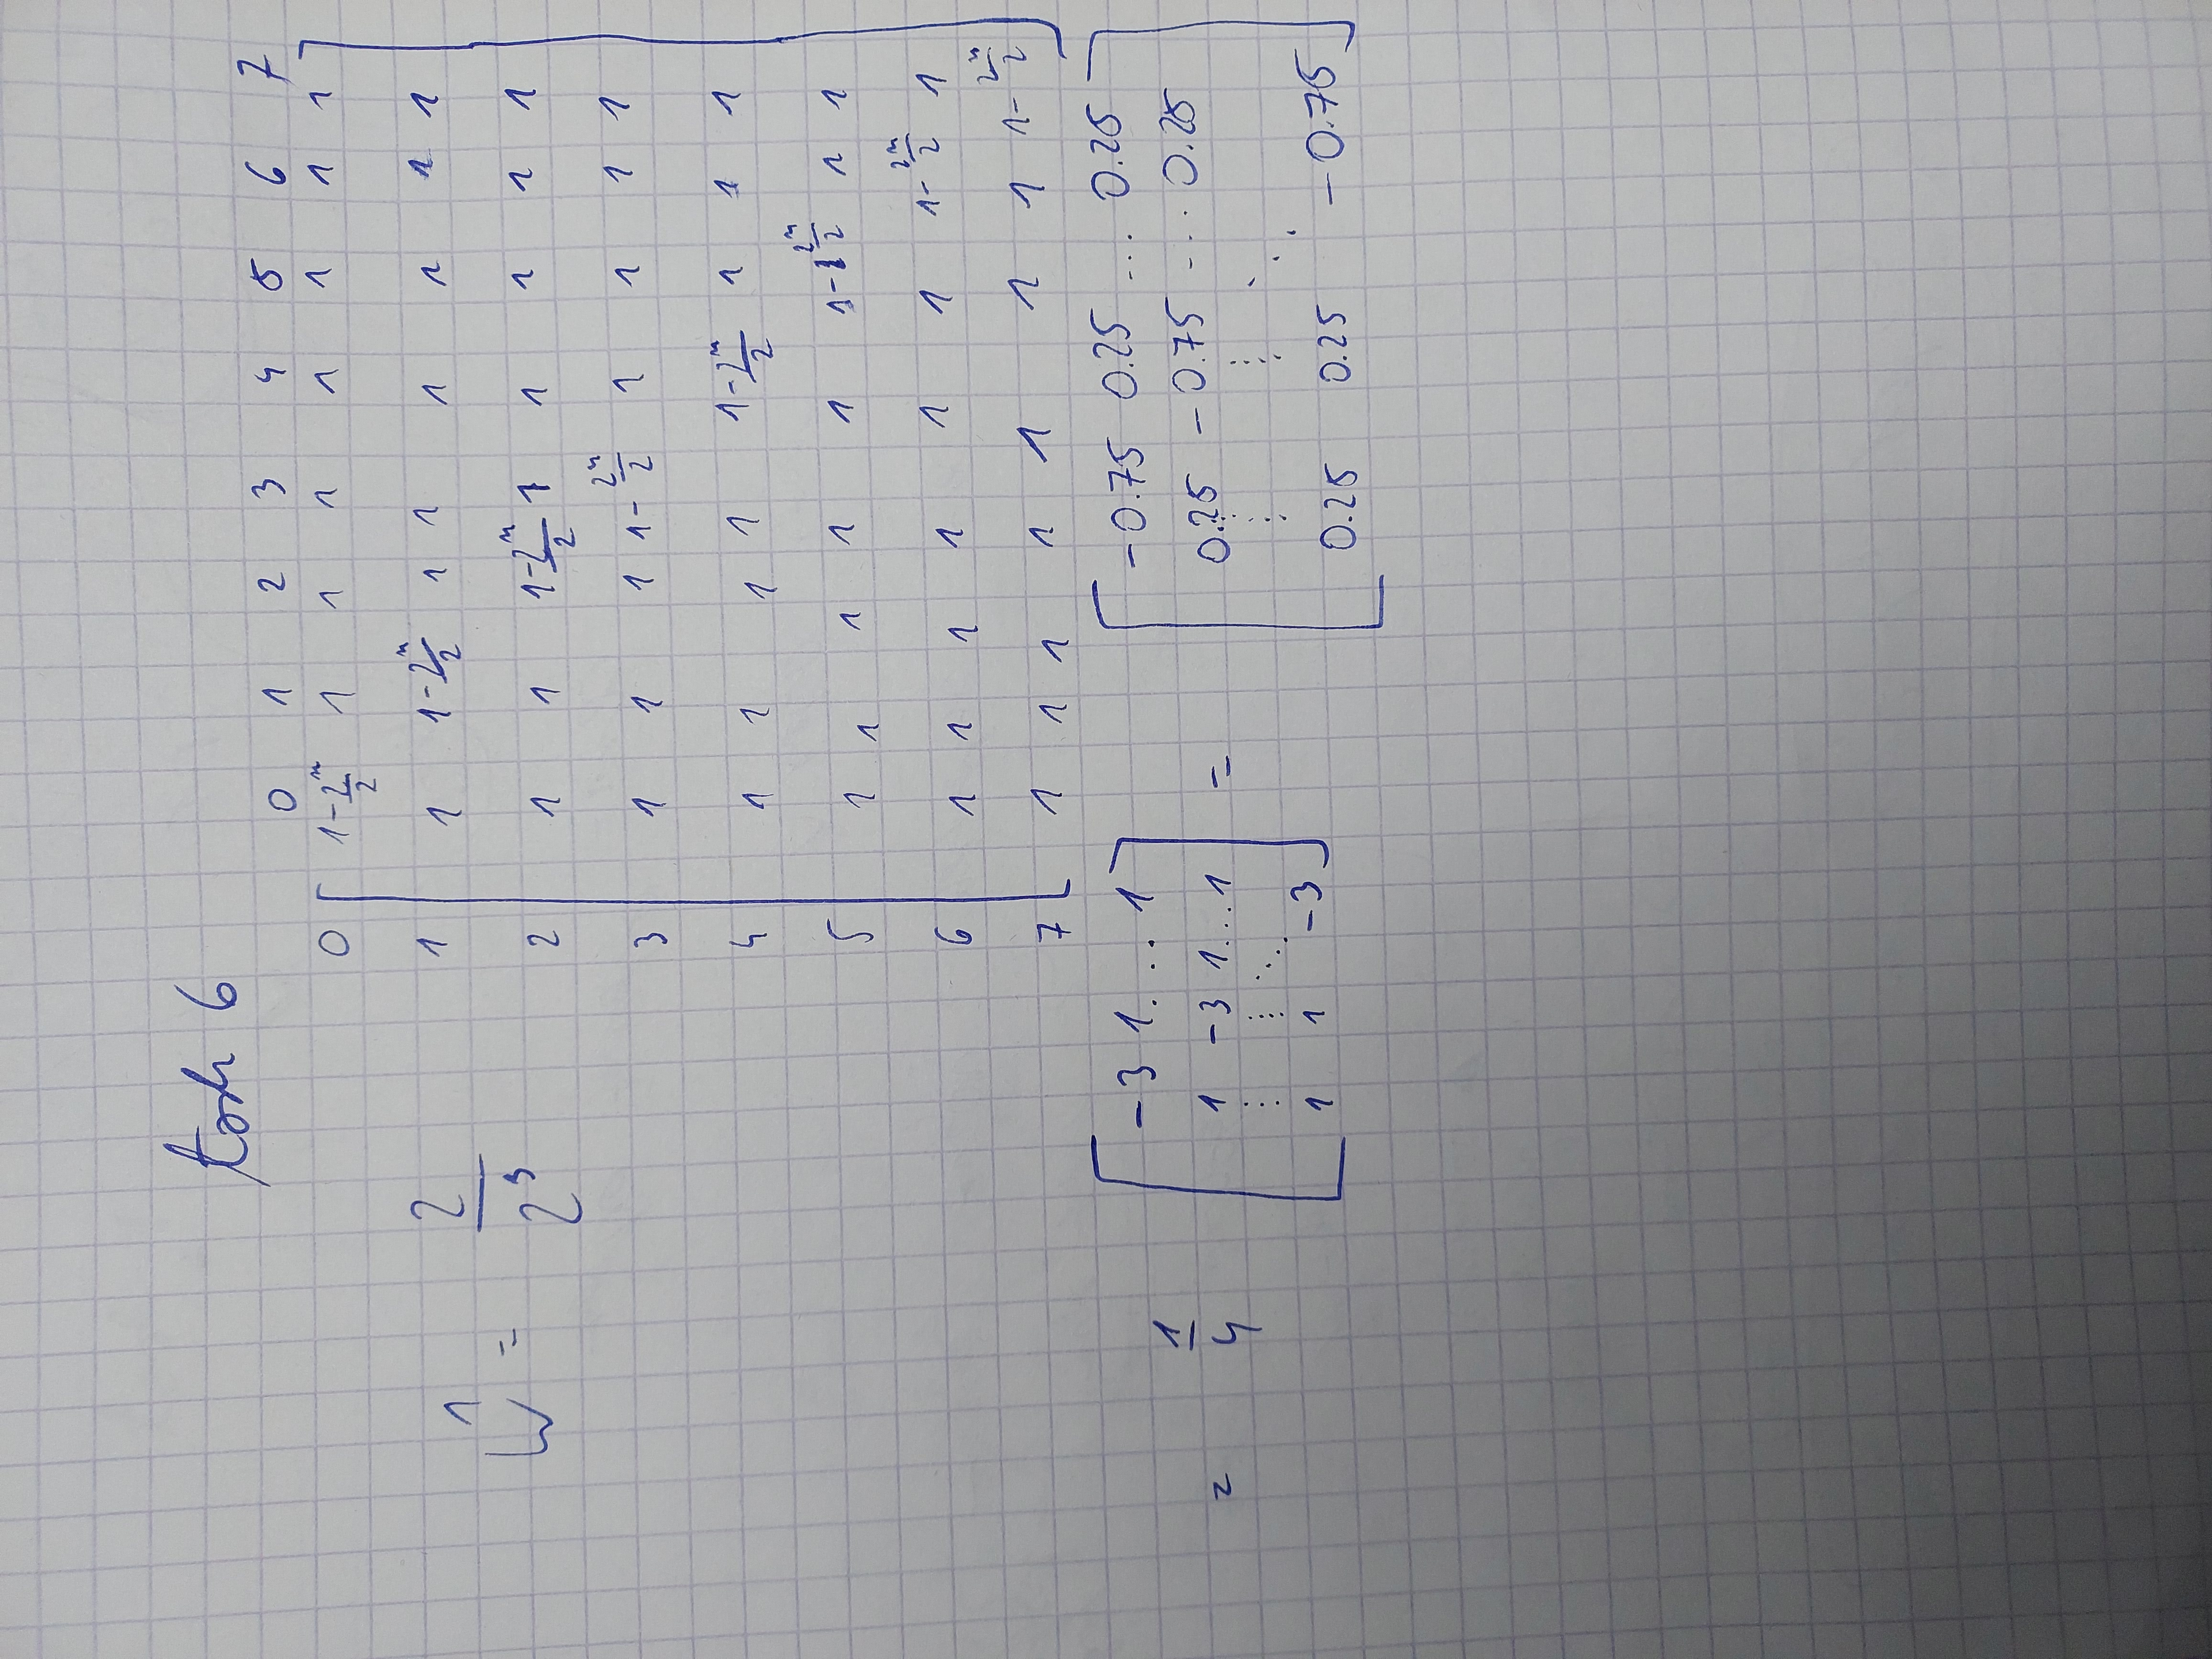

In [2]:
Image(filename="images/task6.jpg")

## Conclusions

The project showcased a successfully construction and implementation of  the XOR oracle, the phase oracle, and the Grover diffusion operator for a 3-qubit system.
The circuits produced the expected unitaries and matched the theoretical formulas. The exercise clearly demonstrates how Grover’s algorithm can be assembled directly from its mathematical definitions.